<a href="https://colab.research.google.com/github/Sajina-2002/India-s-Import-Analysis-from-oceanic-countries-PYTHON-Data-analysis-/blob/main/FINAL_PROJECT(India's_Import_Analysis_from_Oceanic_Countries).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **India's Import Analysis from Oceanic Countries: A Data-Driven Trade Insight**

##**Objective**
1.To analyze total import value from oceanic countries.

2.To Identify top contributing countries.

3.To find out most Imported commodities.

4.Discover Trends and Relationships between Countries and Commodities.

5.To Analyze India's import growth from oceanic countries from 2015-2025.





## **Outcome**

The project helps to analyze India's Import patterns from oceanic countries between 2015 and 2025 by examining country-wise, commodity-wise and state-wise import data to identify major trade patterns ,high-value commodities and key trends that can help understand India's trade dependency and opportunities for better decision-making.

## **Domain**
**COMMERCE**

##**Dataset Information**

**Source:** India Data Portal <font color="blue"><u>  
 https://indiadataportal.com/p/import-trade-statistics/r/mci-tradestat_import_lfy-cn-mn-oce  </font></u>

**Timeline** : Data collected during the year from 2015 to 2025

**Features Description:**

* **date**- at which year it got imported along with month and date

* **country_name** - from which country it's got imported

* **alpha_3_code**- country's 3 letters code(AUS,FJI etc)

* **country_code** - It's code number

* **sub_region**- country's sub region

* **sub_region_code** - country's sub region code

* **HS_code**- (Harmonized system code) It is a international product classification used in import and export

* **commodity** - imported commodity name

* **units**-  type of measurment units(kgs,mts etc)

* **value_in_qn** - value in quantities

* **value_in_rs**- currency value in rupees

* **value_in_dl** -currency value in dollars

# **1.Data Loading and Initial Overview**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
url='https://raw.githubusercontent.com/Sajina-2002/India-s-Imports-from-Oceanic-Countries/refs/heads/main/imports-from-oceanic-countries.csv'
df=pd.read_csv(url)
df.head()

,id,date,country_name,alpha_3_code,country_code,region,region_code,sub_region,sub_region_code,hs_code,commodity,unit,value_qt,value_rs,value_dl
0,0,01-01-2015,American Samoa,ASM,16,Oceania,9,Polynesia,61,71049000,*Othr Syn/Recnctrctd Prcs/Semi Prcs Stones,Kgs,1.96,37.08,0.06
1,1,01-01-2015,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,2044200,"Other Cuts Of Sheep With Bone In, Frozen",Kgs,1.04,14.47,0.02
2,2,01-01-2015,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,2044300,"Boneless Meat Of Sheep, Frozen",Kgs,0.30,1.93,0.00
3,3,01-01-2015,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,4090000,Natural Honey,Kgs,7.56,13.38,0.02
4,4,01-01-2015,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,7131000,*Peas (Pisum Sativum) Dried And Shld,Kgs,8900.59,2370.22,3.81


In [ ]:
df.tail()

,id,date,country_name,alpha_3_code,country_code,region,region_code,sub_region,sub_region_code,hs_code,commodity,unit,value_qt,value_rs,value_dl
95071,95071,01-07-2025,United States Minor Outlying Islands,UMI,581,Oceania,9,Micronesia,57,85365090,Othr Switches,Nos,12.0,0.01,0.00
95072,95072,01-07-2025,United States Minor Outlying Islands,UMI,581,Oceania,9,Micronesia,57,85381090,"Bords,Panels,Consoles Etc.Fr Othr Use",Kgs,1.0,0.00,0.00
95073,95073,01-07-2025,United States Minor Outlying Islands,UMI,581,Oceania,9,Micronesia,57,85389000,Other Parts Of Hdg 8538,Kgs,2347.0,0.13,0.02
95074,95074,01-07-2025,United States Minor Outlying Islands,UMI,581,Oceania,9,Micronesia,57,85444299,Othr Elctrc Cndctrs Fitted Wth Connctrs Used I...,Mtr,2800.0,0.03,0.00
95075,95075,01-07-2025,Vanuatu,VUT,548,Oceania,9,Melanesia,54,12119049,Other Roots And Rhizomes Frsh/Drd W/N Cut Crsh...,Kgs,6650.0,1.23,0.14


In [ ]:
df.shape

(95076, 15)

In [ ]:
df.columns

Index(['id', 'date', 'country_name', 'alpha_3_code', 'country_code', 'region',
       'region_code', 'sub_region', 'sub_region_code', 'hs_code', 'commodity',
       'unit', 'value_qt', 'value_rs', 'value_dl'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95076 entries, 0 to 95075
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               95076 non-null  int64  
 1   date             95076 non-null  object 
 2   country_name     95076 non-null  object 
 3   alpha_3_code     95076 non-null  object 
 4   country_code     95076 non-null  int64  
 5   region           95076 non-null  object 
 6   region_code      95076 non-null  int64  
 7   sub_region       95076 non-null  object 
 8   sub_region_code  95076 non-null  int64  
 9   hs_code          95076 non-null  int64  
 10  commodity        95076 non-null  object 
 11  unit             95075 non-null  object 
 12  value_qt         95076 non-null  float64
 13  value_rs         95076 non-null  float64
 14  value_dl         95076 non-null  float64
dtypes: float64(3), int64(5), object(7)
memory usage: 10.9+ MB


In [ ]:
df[["value_qt","value_rs","value_dl"]].describe()

,value_qt,value_rs,value_dl
count,9.507600e+04,9.507600e+04,95076.000000
mean,3.827636e+05,1.036961e+03,1.548937
std,2.366952e+07,1.724381e+04,23.732325
min,0.000000e+00,0.000000e+00,0.000000
25%,2.000000e-02,9.200000e-01,0.000000
50%,3.400000e-01,6.320000e+00,0.010000
75%,1.800000e+01,3.776250e+01,0.060000
max,3.101283e+09,1.145176e+06,1481.100000


From Describe,I can able to identify:

The dataset contains 95,076 observations.

**In Quantity basis**

*Mean>Median (mean= 3,82,764),(median(50%)=0.34)

The average quantity is much higher than the median, indicating a highly *"Right skewed distribution"*.

**In Value basis(In Rs)**

*Mean>Median (Mean=1036.97),(Median(50%)=6.32)

The value_rs column is positively *Right skewed* because the mean (1036.97) is much higher than the median (6.32). This indicates that while most import transactions have relatively low rupee values, a small number of transactions have exceptionally high values, increasing the average.










In [ ]:
skew_qt=df["value_qt"].skew()
print("skewness for value in quantity=",skew_qt,"its greater than '0', so its 'Highly Right skewed distribution'.")

skew_rs=df["value_rs"].skew()
print("skewness for value in rupees=",skew_rs,"its greater than '0', so its 'Highly Right skewed distribution'.")

skewness for value in quantity= 94.34715675253616 its greater than '0', so its 'Highly Right skewed distribution'.
skewness for value in rupees= 33.45347339235526 its greater than '0', so its 'Highly Right skewed distribution'.


## **Data Cleaning and Pre-processing**



In [ ]:
#handle missing values
df.isnull().sum()

,0
id,0
date,0
country_name,0
alpha_3_code,0
country_code,0
region,0
region_code,0
sub_region,0
sub_region_code,0
hs_code,0


In [ ]:
# unit= 1 missing values
df['unit'].fillna('unknown',inplace=True)
df.drop_duplicates(inplace=True)

/tmp/ipykernel_5299/3238731301.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['unit'].fillna('unknown',inplace=True)


In [ ]:
#date convert
df['date']=pd.to_datetime(df['date'])

In [ ]:
#create new columns(year and month)
df['year']=df['date'].dt.year
df['month']=df['date'].dt.month_name()

In [ ]:
df.head()

,id,date,country_name,alpha_3_code,country_code,region,region_code,sub_region,sub_region_code,hs_code,commodity,unit,value_qt,value_rs,value_dl,year,month
0,0,2015-01-01,American Samoa,ASM,16,Oceania,9,Polynesia,61,71049000,*Othr Syn/Recnctrctd Prcs/Semi Prcs Stones,Kgs,1.96,37.08,0.06,2015,January
1,1,2015-01-01,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,2044200,"Other Cuts Of Sheep With Bone In, Frozen",Kgs,1.04,14.47,0.02,2015,January
2,2,2015-01-01,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,2044300,"Boneless Meat Of Sheep, Frozen",Kgs,0.30,1.93,0.00,2015,January
3,3,2015-01-01,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,4090000,Natural Honey,Kgs,7.56,13.38,0.02,2015,January
4,4,2015-01-01,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,7131000,*Peas (Pisum Sativum) Dried And Shld,Kgs,8900.59,2370.22,3.81,2015,January


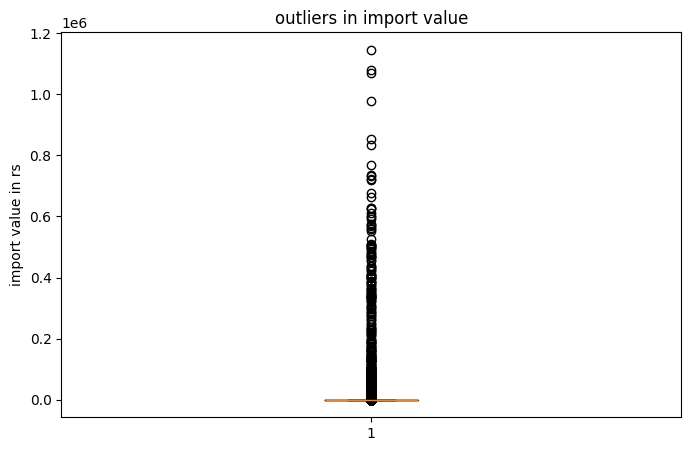

In [ ]:
#To find outliers using box plot
plt.figure(figsize=(8,5))
plt.boxplot(df['value_rs'])
plt.title('outliers in import value')
plt.ylabel('import value in rs')
plt.show()

In [ ]:
q1=df['value_rs'].quantile(0.25)
q3=df['value_rs'].quantile(0.75)

IQR = q3-q1
lower_bound=q1-1.5*IQR
upper_bound=q3+1.5*IQR
outliers=df[(df['value_rs']<lower_bound)|(df['value_rs']>upper_bound)]
#number of outliers
print("number of outliers:",len(outliers))
#percentage of outliers
print("percentage of outliers:",round(len(outliers)/len(df)*100,2),'%')


number of outliers: 14688
percentage of outliers: 15.45 %


##Data preprocessing
* The box plot reveals a significant number of outliers in the import value (value_rs). These outliers correspond to unusually high-value import transactions. Since this dataset contains real international trade records, these extreme values are considered valid observations rather than data errors and were retained for further business analysis.

* Removed duplicate records

* Checked missing values

* Converted date into datetime format

* Created year and month columns

##EDA and Visualizations



In [ ]:
df.head()

,id,date,country_name,alpha_3_code,country_code,region,region_code,sub_region,sub_region_code,hs_code,commodity,unit,value_qt,value_rs,value_dl,year,month
0,0,2015-01-01,American Samoa,ASM,16,Oceania,9,Polynesia,61,71049000,*Othr Syn/Recnctrctd Prcs/Semi Prcs Stones,Kgs,1.96,37.08,0.06,2015,January
1,1,2015-01-01,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,2044200,"Other Cuts Of Sheep With Bone In, Frozen",Kgs,1.04,14.47,0.02,2015,January
2,2,2015-01-01,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,2044300,"Boneless Meat Of Sheep, Frozen",Kgs,0.30,1.93,0.00,2015,January
3,3,2015-01-01,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,4090000,Natural Honey,Kgs,7.56,13.38,0.02,2015,January
4,4,2015-01-01,Australia,AUS,36,Oceania,9,Australia and New Zealand,53,7131000,*Peas (Pisum Sativum) Dried And Shld,Kgs,8900.59,2370.22,3.81,2015,January


##*UNIVARIATE ANALYSIS*

##**Frequency Bins**

1.How are India's import values distributed across all import transactions?

COLUMNS USED: value_rs







value_rs
(0.0, 10.0]                52283
(10.0, 100.0]              27071
(100.0, 1000.0]             9740
(1000.0, 10000.0]           3347
(10000.0, 100000.0]          897
(100000.0, 1000000.0]        168
(1000000.0, 1145175.68]        3
Name: count, dtype: int64


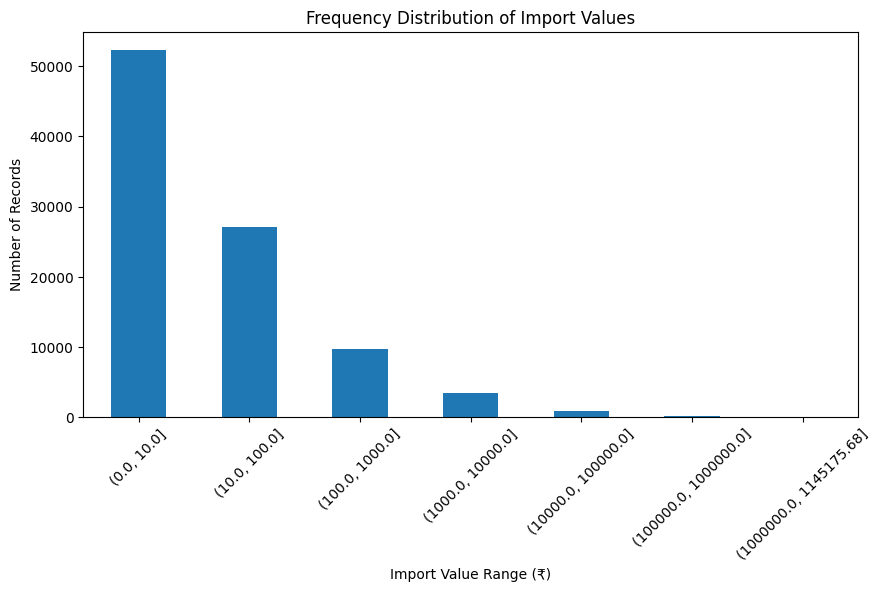

In [ ]:
bins = [0, 10, 100, 1000, 10000, 100000, 1000000, df['value_rs'].max()]

frequency = pd.cut(df['value_rs'], bins=bins).value_counts().sort_index()

print(frequency)

frequency.plot(kind='bar', figsize=(10,5))

plt.title("Frequency Distribution of Import Values")
plt.xlabel("Import Value Range (₹)")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()




* From the frequency distribution shows that the majority of India's import transactions from the selected countries are of low monetary value.

 * More than half of the records (52,283) fall within the ₹0–₹10 range, while the number of transactions decreases steadily as the import value increases.

 * Only 3 transactions have an import value exceeding ₹1 crore, indicating that very high-value imports are extremely rare.
  
 * This distribution is highly positively (right) skewed, meaning there are many low-value transactions and only a few exceptionally high-value transactions.

##**Count plot**

2.Which oceanic countries have a highest number of import transactions with India?

COLUMNS USED:country_name

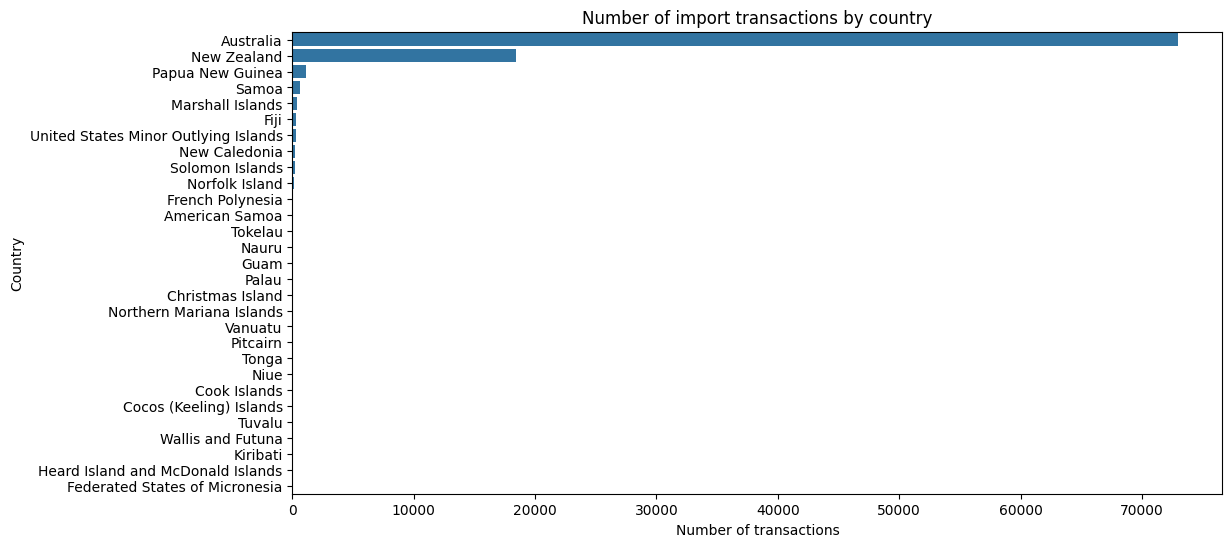

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(y="country_name",
              data=df,
              order=df["country_name"].value_counts().index
              )

plt.title("Number of import transactions by country")
plt.xlabel("Number of transactions")
plt.ylabel("Country")
plt.show()

 * Australia records the highest number of import transactions, indicating that it is India's most active trading partner in terms of transaction frequency. It is followed by New Zealand, Papua New Guinea, Samoa, Marshall Islands. On the other hand, Federated States of Micronesia, Heard Island and McDonald Islands, Kiribati, Vanuatu, and Tuvalu have the lowest number of import transactions, suggesting relatively limited trade activity with India.

* The analysis indicates that India's import transactions are concentrated among a few major trading partners, while trade with several smaller island nations is comparatively limited. This difference may be influenced by factors such as economic size, availability of exportable goods, geographical location, and the strength of bilateral trade relationships.

##*BIVARIATE ANALYSIS*

##**Scatter plot**

3.Is there a relationship between the quantity of goods imported and their import value?

**COLUMNS USED**:Commodity,value_rs




In [ ]:
#data grouping
commodity_value = (
    df.groupby('commodity')['value_rs']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
#the dataset has many outliers, so used a logarithmic scale:
#(plotly express)
fig = px.scatter(
    df,
    x='value_qt',
    y='value_rs',
    log_x=True,
    log_y=True,
    title='Import Quantity vs Import Value (Log Scale)',
    labels={
        'value_qt': 'Import Quantity (Log Scale)',
        'value_rs': 'Import Value (₹) (Log Scale)'
    },
    opacity=0.6
)

fig.show()

* The scatter plot shows an overall upward trend, indicating a **positive relationship** between import quantity and import value. As the quantity of imported goods increases, the import value also tends to increase. However, the points are not perfectly aligned, suggesting that other factors such as commodity type, product quality, and unit price also influence the total import value.

* The analysis suggests that import quantity is an important factor affecting import value, but it is not the only factor. Some commodities are expensive even when imported in small quantities, while others are imported in large quantities at lower prices. Therefore, import value depends on both the volume of imports and the economic value of the commodities.

##**Bar plot**

4.Which countries contribute the highest import value to India?

5.Which Commodities account for highest import expenditure?

**COLUMNS USED**: Country_name, value_rs

**COLUMNS USED**:Commodity,value_rs

In [ ]:
# Group the data
country_value = (
    df.groupby('country_name')['value_rs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
# Create the bar chart(plotly_express)
fig = px.bar(
    country_value,
    x='country_name',
    y='value_rs',
    text='value_rs',
    title='Top 10 Countries by Total Import Value'
)

# Display exact values on bars
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.update_layout(
    xaxis_title='Country',
    yaxis_title='Total Import Value (₹)'
)

fig.show()



* The bar chart illustrates the Top 10 countries contributing to India's total import value. Among all the countries, Australia contributes the highest import value by a substantial margin, indicating that it is the most significant trading partner within the selected dataset. New Zealand ranks second but has a considerably lower import value compared to Australia. The remaining countries, including Solomon Islands, New Caledonia, Samoa, Nauru, Marshall Islands, Palau, and Fiji, contribute relatively smaller shares of the total import value. The noticeable gap between Australia and the other countries suggests that India's import expenditure is heavily concentrated on imports from Australia.

* The analysis indicates that India has a strong import dependence on Australia among the countries included in this dataset. This may be due to Australia's exports of high-value commodities such as coal, minerals, metals, agricultural products, or other raw materials. In contrast, the other countries contribute a much smaller share of India's import value, indicating comparatively limited trade in terms of monetary value.

In [ ]:
# Group data by commodity and calculate total import value
top10_commodities = (
    df.groupby('commodity')['value_rs']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

# Create interactive bar chart(plotpy_express)
fig = px.bar(
    top10_commodities,
    x='commodity',
    y='value_rs',
    text='value_rs',
    title='Top 10 Commodities by Total Import Value',
    color='value_rs'
)

# Display values on top of bars
fig.update_traces(
    texttemplate='%{text:,.2f}',
    textposition='outside'
)

fig.show()

* The analysis shows that India's imports are heavily focused on energy resources, industrial raw materials, and essential commodities. High import values for coal, natural gas, copper ores, and alumina highlight the country's dependence on imported resources to support manufacturing, electricity generation, and infrastructure development. The presence of agricultural commodities such as chickpeas and lentils also reflects the importance of imports in meeting domestic food demand when local production is insufficient.


* The bar chart reveals that Coking Coal is the dominant imported commodity in terms of monetary value, followed by other coal products, gold, steam coal, and copper ores. This indicates that India's import expenditure is largely driven by commodities that support industrial production, energy security, and economic growth.

##**Line plot**
6.How has India's import value from oceanic countries changed over the years,and what factors influenced these changes?

In [ ]:
#data grouping
year_value = df.groupby('year', as_index=False)['value_rs'].sum()
year_value


fig = px.line(
    year_value,
    x='year',
    y='value_rs',
    title='Year-wise Total Import Value of India from Oceanic Countries',
    markers=True,
    labels={
        'year': 'Year',
        'value_rs': 'Import Value (₹)'
    }
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Year',
    yaxis_title='Total Import Value (₹)',
    template='plotly_white'
)

fig.show()


* The analysis indicates that India's imports from Oceanic countries are highly sensitive to global economic conditions and commodity markets. Rather than increasing steadily every year, import values respond to international events and domestic industrial demand. The sharp decline in 2020 highlights the impact of global disruptions, while the rapid recovery in 2021–2022 demonstrates India's growing demand for essential commodities as economic activity resumed.


* COVID-19 pandemic and global supply chain disruptions
* International commodity price fluctuations (coal, LNG, gold, copper, etc.)
* India's industrial and energy demand
* Government trade policies and import regulations
* Exchange rate (Indian Rupee vs US Dollar)
* Shipping and freight costs
* Inflation and global economic conditions
* Geopolitical events affecting international trade




##**Pie chart**

7.Which sub region contributes the highest import value to India?

In [ ]:
# Group data by sub-region
subregion_value = (
    df.groupby('sub_region')['value_rs']
      .sum()
      .reset_index()
)

# Create Pie Chart
fig = px.pie(
    subregion_value,
    names='sub_region',
    values='value_rs',
    title='Share of Total Import Value by Sub-region',
    hole=0.3
)

fig.update_traces(
    textinfo='percent+label',
    textposition='inside'
)





* Tthe chart highlights that India's import dependency within Oceania is heavily concentrated on the Australia and New Zealand sub-region, while trade with other Oceania sub-regions remains comparatively minimal.

* India relies heavily on the Australia and New Zealand sub-region for strategic imports such as minerals, energy resources, and agricultural commodities. While this partnership ensures a stable supply of essential resources, it also indicates a high dependence on one sub-region. Diversifying import sources across other Oceania regions could help reduce supply-chain risks and improve long-term trade resilience.





##*MULTIVARIATE ANALYSIS*

##**SANKEY DIAGRAM**

From which sub region,country and what are commodities has been imported?



In [ ]:
import plotly.graph_objects as go

# grouping top 10 commodities
top_commodities = (
    df.groupby('commodity')['value_rs']
      .sum()
      .nlargest(10)
      .index
)

data = df[df['commodity'].isin(top_commodities)]

# Create labels
labels = pd.concat([
    data['sub_region'],
    data['country_name'],
    data['commodity']
]).unique().tolist()

label_index = {label: i for i, label in enumerate(labels)}

source = []
target = []
value = []

# Sub-region → Country
flow1 = data.groupby(['sub_region', 'country_name'])['value_rs'].sum().reset_index()

for _, row in flow1.iterrows():
    source.append(label_index[row['sub_region']])
    target.append(label_index[row['country_name']])
    value.append(row['value_rs'])

# Country to Commodity
flow2 = data.groupby(['country_name', 'commodity'])['value_rs'].sum().reset_index()

for _, row in flow2.iterrows():
    source.append(label_index[row['country_name']])
    target.append(label_index[row['commodity']])
    value.append(row['value_rs'])

# Sankey Diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title_text="Flow of India's Imports: Sub-region → Country → Commodity",
    font_size=10
)

fig.show()

* The diagram clearly shows that the Australia and New Zealand sub-region contributes the overwhelming majority of India's imports from Oceania. The flow from this sub-region to Australia is significantly wider than all other flows, indicating that Australia is India's dominant trading partner within Oceania.
* From Australia, the imports are concentrated in a few high-value commodities. Among these, Coking Coal has the widest flow, making it the single largest imported commodity. Other important imports include Other Coal, Non-Monetary Gold, Steam Coal, Copper Ores and Concentrates, Liquefied Natural Gas (LNG), Alumina, Chickpeas, Lentils, and Others. These commodities are mainly used in India's steel industry, power generation, manufacturing, and food processing sectors.
* In contrast, countries such as Fiji, Samoa, Solomon Islands, Papua New Guinea, Marshall Islands, Palau, Nauru, Tokelau, Wallis and Futuna, Pitcairn, and American Samoa contribute comparatively small import values, as indicated by their very narrow flows.


## **Data Import**




In [ ]:
df.to_csv("India's import analysis from oceanic countries cleaned data.csv",index=False)
from google.colab import files
files.download("India's import analysis from oceanic countries cleaned data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 ## **Documentation, Insights and Presentation**




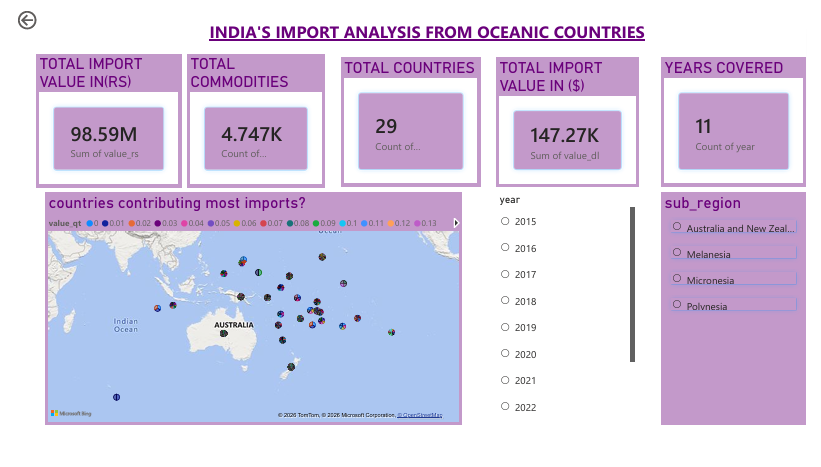

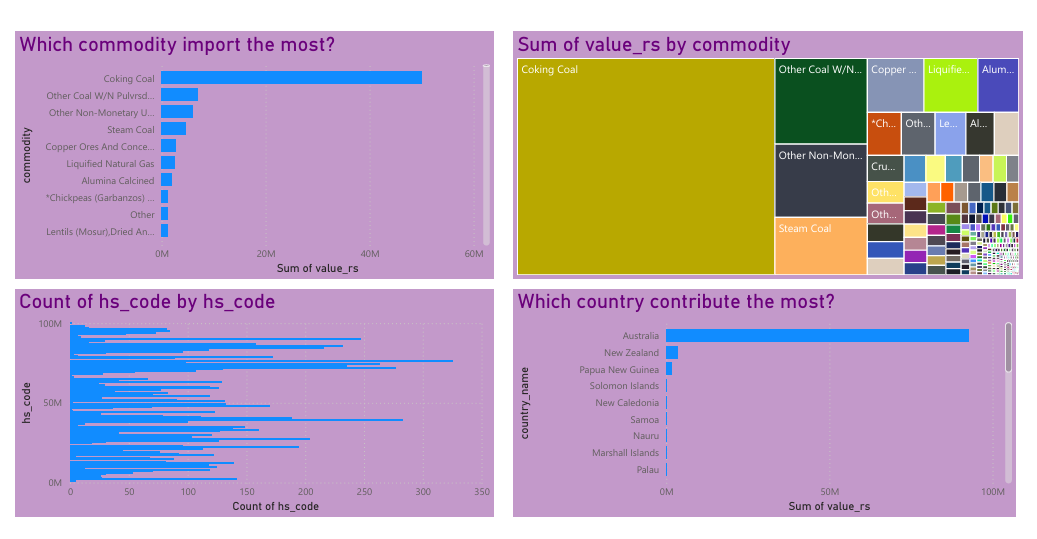

The dashboard provides an interactive overview of India's imports from Oceanic countries.

Users can:

* Filter by year.

* Filter by sub-region.

* Identify top commodities.

* View country contributions.

* Analyze geographical distribution.

* Understand commodity dominance.

* The dashboard enables decision-makers to quickly identify major suppliers and trading patterns.





## **Final Overall Insights:**
* Australia is India's dominant trading partner in Oceania.
* Australia alone contributes the majority of India's import value.
* Coal is the most imported commodity, highlighting India's dependence on imported energy resources.
* Gold, LNG, copper ores, and alumina are important industrial imports.
* More than 97% of imports originate from Australia and New Zealand.
* Import values recovered strongly after the COVID-19 period.
* Most transactions are low-value imports, while only a few large transactions contribute significantly to the overall import value.
* The positive relationship between import quantity and value suggests that larger shipments generally result in higher import expenditure.

# Conclusion

This project successfully analyzed India's imports from Oceanic countries between 2015 and 2025 using Python for data preprocessing and exploratory data analysis and Power BI for interactive dashboard development.
The analysis revealed that Australia is India's primary trading partner, contributing the highest import value and transaction volume. Energy commodities, particularly coking coal, dominate India's imports, emphasizing the country's dependence on imported industrial resources. The dashboard effectively highlights import trends, commodity distribution, country contributions, and regional trade patterns, enabling data-driven decision-making.
Overall, this project demonstrates how data analytics techniques can transform raw trade data into meaningful business insights that support policymakers, economists, and business organizations in making informed strategic decisions.
